# Distance vs Decoder Latency

**Purpose:** Plot decoder latency as a function of code distance for Simple NN, gSAGE, and MWPM.

**Data source:** `code/results/nn_vs_gnn_comparison/plots/final/inference_speeds.csv`

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# Resolve workspace root from notebook location
_here = Path(".").resolve()
_candidates = [_here, _here.parent, _here.parent.parent, _here.parent.parent.parent]
WORKSPACE_ROOT = next(
    (p for p in _candidates if (p / "code" / "results" / "nn_vs_gnn_comparison").exists()),
    _here
)

DATA_PATH    = WORKSPACE_ROOT / "code/results/nn_vs_gnn_comparison/plots/final/inference_speeds.csv"
SCALING_PATH = WORKSPACE_ROOT / "code/results/nn_vs_gnn_comparison/plots/final/scaling_patterns.csv"
PLOTS_DIR    = Path("plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Consistent colors + labels used across all charts in this notebook
MODEL_STYLE = {
    #  key in CSV  : (display label,         color,     marker)
    'NN'  : ('Simple NN',          '#2980B9', 'D'),
    'GNN' : ('GNN (GraphSAGE)',    '#E74C3C', 'o'),
    'MWPM': ('MWPM',               '#F39C12', 's'),
}

print("Data file:    ", DATA_PATH,    "—", "✓" if DATA_PATH.exists()    else "✗")
print("Scaling file: ", SCALING_PATH, "—", "✓" if SCALING_PATH.exists() else "✗")

Data file:     /Users/billxu/quantum-error-correction/code/results/nn_vs_gnn_comparison/plots/final/inference_speeds.csv — ✓
Scaling file:  /Users/billxu/quantum-error-correction/code/results/nn_vs_gnn_comparison/plots/final/scaling_patterns.csv — ✓


In [21]:
df = pd.read_csv(DATA_PATH)
df['distance'] = df['distance'].astype(int)
print(df.to_string(index=False))

 distance model  latency_us  throughput_samples_per_sec  batch_size
        3   GNN   40.640831                2.460580e+04        64.0
        3  MWPM    0.110126                9.080546e+06         NaN
        3    NN    4.123607                2.425062e+05        64.0
        5   GNN   41.135302                2.431002e+04        64.0
        5  MWPM    0.975151                1.025482e+06         NaN
        5    NN    4.034610                2.478554e+05        64.0
        7   GNN   43.198180                2.314912e+04        64.0
        7  MWPM    3.421330                2.922840e+05         NaN
        7    NN    4.744225                2.107826e+05        64.0
        9   GNN   44.345655                2.255012e+04        64.0
        9  MWPM    8.295479                1.205476e+05         NaN
        9    NN    4.758543                2.101484e+05        64.0
       11   GNN   40.653343                2.459822e+04        64.0
       11  MWPM   16.068187                6.223

Plot saved to: plots/decoder_latency_vs_distance.png


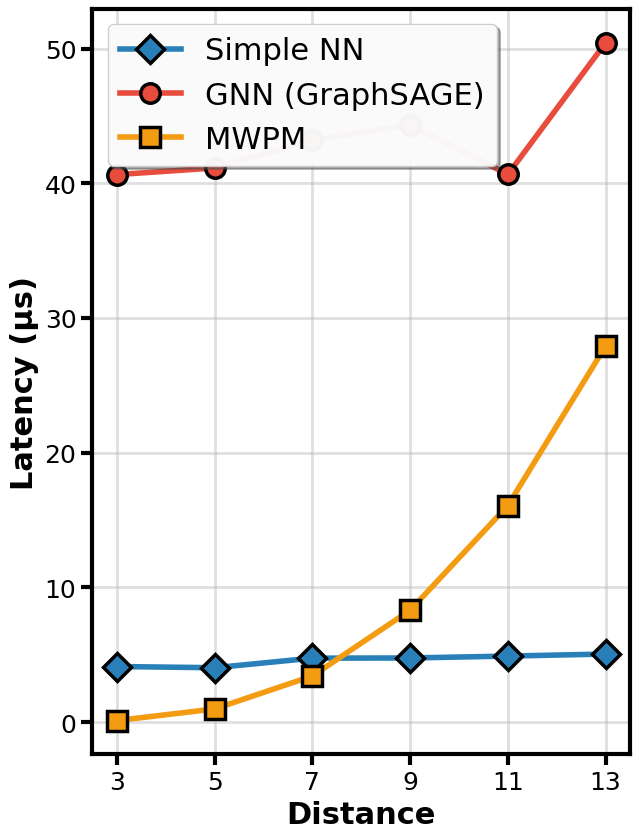

In [22]:
def get_series(model_key):
    sub = df[df['model'] == model_key].sort_values('distance')
    return sub['distance'].tolist(), sub['latency_us'].tolist()

all_distances = sorted(df['distance'].unique())

fig, ax = plt.subplots(figsize=(6.5, 8.5))

for model_key, (label, color, marker) in MODEL_STYLE.items():
    distances, latencies = get_series(model_key)
    ax.plot(
        distances, latencies,
        marker=marker, linestyle='-', label=label,
        color=color, linewidth=4,
        markersize=14, markeredgecolor='black', markeredgewidth=2.5,
    )

ax.set_xlabel('Distance', fontsize=22, fontweight='bold')
ax.set_ylabel('Latency (µs)', fontsize=22, fontweight='bold')
ax.set_xticks(all_distances)
ax.tick_params(axis='both', labelsize=18, width=3, length=8)
ax.legend(fontsize=22, frameon=True, shadow=True, fancybox=True, framealpha=0.95, loc='upper left')
ax.grid(True, alpha=0.4, linestyle='-', linewidth=2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(3)
    spine.set_edgecolor('black')

plt.tight_layout()
save_path = PLOTS_DIR / 'decoder_latency_vs_distance.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Plot saved to: {save_path}')
plt.show()
plt.close()

Fitted exponents: {'NN': 0.16, 'GNN': 0.1, 'MWPM': 3.34}
  NN    a=3.3560  n=0.1588  (scaling_patterns n=0.16)
  GNN   a=35.3038  n=0.1042  (scaling_patterns n=0.10)
  MWPM  a=0.0053  n=3.3380  (scaling_patterns n=3.34)
Plot saved to: plots/decoder_latency_vs_distance_extended.png


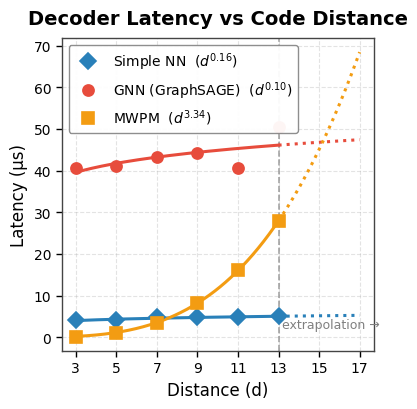

In [29]:

# ── Load fitted exponents from scaling_patterns.csv ───────────────────────────
df_scaling = pd.read_csv(SCALING_PATH)
# Map CSV "Decoder" column to our model keys
decoder_map = {'NN': 'NN', 'GNN': 'GNN', 'MWPM': 'MWPM'}
exponents = {
    decoder_map[row['Decoder']]: float(row['Exponent (d^n)'])
    for _, row in df_scaling.iterrows()
    if row['Decoder'] in decoder_map
}
print("Fitted exponents:", exponents)

# ── Power-law fit: latency = a * d^n ──────────────────────────────────────────
def power_law(d, a, n):
    return a * np.power(d, n)

fits = {}
for model_key in MODEL_STYLE:
    sub = df[df['model'] == model_key].sort_values('distance')
    d_data = sub['distance'].values.astype(float)
    y_data = sub['latency_us'].values
    popt, _ = curve_fit(power_law, d_data, y_data, p0=[1.0, exponents[model_key]], maxfev=10000)
    fits[model_key] = popt  # (a, n)
    print(f"  {model_key:4s}  a={popt[0]:.4f}  n={popt[1]:.4f}  (scaling_patterns n={exponents[model_key]:.2f})")

# ── Plot: observed data + solid fit (d≤13) + dotted extrapolation (d>13) ──────
D_OBS_MAX = 13
D_EXT_MAX = 17
D_TICKS   = [3, 5, 7, 9, 11, 13, 15, 17]

d_solid  = np.linspace(3,          D_OBS_MAX, 300)
d_dotted = np.linspace(D_OBS_MAX,  D_EXT_MAX, 300)

fig, ax = plt.subplots(figsize=(4, 4.2))

for model_key, (label, color, marker) in MODEL_STYLE.items():
    a_fit, n_fit = fits[model_key]
    eq_str = f"$d^{{{n_fit:.2f}}}$"

    # Solid fitted curve over observed range
    ax.plot(d_solid,  power_law(d_solid,  a_fit, n_fit),
            color=color, linewidth=2.2, linestyle='-',  zorder=2)
    # Dotted extrapolation beyond d=13
    ax.plot(d_dotted, power_law(d_dotted, a_fit, n_fit),
            color=color, linewidth=2.2, linestyle=':',  zorder=2)

    # Observed data points
    sub = df[df['model'] == model_key].sort_values('distance')
    ax.plot(sub['distance'], sub['latency_us'],
            marker=marker, linestyle='', color=color,
            markersize=8, markeredgecolor=color, markeredgewidth=1.2,
            label=f"{label}  ({eq_str})", zorder=3)

# Vertical boundary at d=13
ax.axvline(x=D_OBS_MAX, color='grey', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)
ax.text(D_OBS_MAX + 0.15, ax.get_ylim()[1] * 0.02, 'extrapolation →',
        fontsize=9, color='grey', va='bottom')

ax.set_title('Decoder Latency vs Code Distance', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Distance (d)', fontsize=12)
ax.set_ylabel('Latency (µs)', fontsize=12)
ax.set_xticks(D_TICKS)
ax.tick_params(axis='both', labelsize=10, width=1, length=4)
ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('#444444')
ax.legend(fontsize=10, frameon=True, fancybox=True,
          shadow=False, framealpha=0.95, edgecolor='#888888',
          loc='upper left')

plt.tight_layout()
save_path = PLOTS_DIR / 'decoder_latency_vs_distance_extended.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print(f'Plot saved to: {save_path}')
plt.show()
plt.close()

# Validation Accuracy vs Distance / Number of Detectors

**Purpose:** Two-panel plot showing how decoder accuracy degrades with increasing code distance.

**Data sources:**
- `final_accuracies.csv` for NN and GNN (d=3,5,7,11,13)
- Training JSONs for d=9 (missing from CSV)
- `evaluation_results.csv` for MWPM accuracy

In [24]:
import json

ACCURACY_CSV = WORKSPACE_ROOT / "code/results/nn_vs_gnn_comparison/plots/final/final_accuracies.csv"
EVAL_CSV     = WORKSPACE_ROOT / "code/nn/distances/results/evaluation_results.csv"

df_acc = pd.read_csv(ACCURACY_CSV)
df_acc['distance'] = df_acc['distance'].astype(int)

nn_acc  = df_acc[df_acc['model'] == 'NN'].sort_values('distance')
gnn_acc = df_acc[df_acc['model'] == 'GNN'].sort_values('distance')

nn_distances  = nn_acc['distance'].tolist()
nn_accuracies = nn_acc['accuracy'].tolist()

gnn_distances  = gnn_acc['distance'].tolist()
gnn_accuracies = gnn_acc['accuracy'].tolist()

# d=9 is missing from final_accuracies.csv — pull from training JSONs
nn_d9_path  = WORKSPACE_ROOT / "code/nn/training/results/revised_training/results.json"
gnn_d9_path = WORKSPACE_ROOT / "code/gSAGE/distances/results/revised_training/d9_training.json"

with open(nn_d9_path) as f:
    nn_results = json.load(f)
nn_d9_val = max(
    (r['val_accuracy'] for r in nn_results if r['distance'] == 9),
    default=None
)

with open(gnn_d9_path) as f:
    gnn_d9 = json.load(f)
gnn_d9_val = gnn_d9['final_metrics']['val_accuracy']

# Insert d=9 in the right position (between d=7 and d=11)
for dists, accs, val in [(nn_distances, nn_accuracies, nn_d9_val),
                         (gnn_distances, gnn_accuracies, gnn_d9_val)]:
    idx = next(i for i, d in enumerate(dists) if d > 9)
    dists.insert(idx, 9)
    accs.insert(idx, val)

# MWPM accuracy from evaluation_results.csv (average across p values per distance)
df_eval = pd.read_csv(EVAL_CSV)
mwpm_by_d = df_eval.groupby('distance')['mwpm_accuracy'].mean().sort_index()
mwpm_distances  = mwpm_by_d.index.tolist()
mwpm_accuracies = mwpm_by_d.values.tolist()

DETECTORS = {3: 24, 5: 120, 7: 336, 9: 720, 11: 1320, 13: 2184}

print("NN:  ", list(zip(nn_distances, [f"{a:.4f}" for a in nn_accuracies])))
print("GNN: ", list(zip(gnn_distances, [f"{a:.4f}" for a in gnn_accuracies])))
print("MWPM:", list(zip(mwpm_distances, [f"{a:.4f}" for a in mwpm_accuracies])))

NN:   [(3, '0.9862'), (5, '0.9750'), (7, '0.8929'), (9, '0.7913'), (11, '0.6289'), (13, '0.5812')]
GNN:  [(3, '0.9869'), (5, '0.9799'), (7, '0.9484'), (9, '0.8886'), (11, '0.8335'), (13, '0.7528')]
MWPM: [(3, '0.9830'), (5, '0.9829'), (7, '0.9851'), (9, '0.9862'), (11, '0.9873'), (13, '0.9877')]


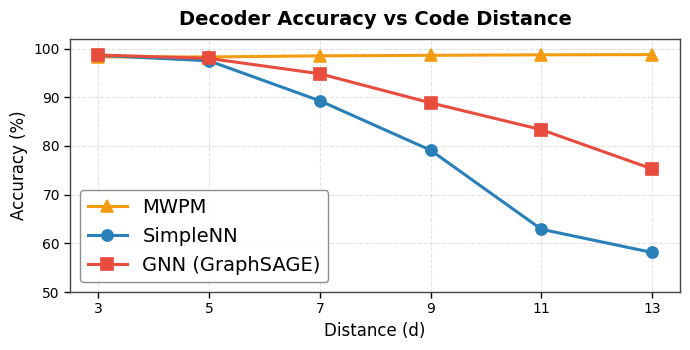

Saved → plots/accuracy_vs_distance.png


In [30]:
STYLE = {
    'NN':   {'label': 'SimpleNN',        'color': '#2980B9', 'marker': 'o'},
    'GNN':  {'label': 'GNN (GraphSAGE)', 'color': '#E74C3C', 'marker': 's'},
    'MWPM': {'label': 'MWPM',            'color': '#F39C12', 'marker': '^'},
}

distances_all = [3, 5, 7, 9, 11, 13]

fig, ax = plt.subplots(figsize=(7, 3.6))

def plot_one(ax, x, y, key, zorder=3):
    s = STYLE[key]
    y_pct = [v * 100 for v in y]
    ax.plot(x, y_pct,
            marker=s['marker'], linestyle='-', color=s['color'],
            linewidth=2.2, markersize=8,
            markeredgecolor=s['color'], markeredgewidth=1.2,
            label=s['label'], zorder=zorder)

plot_one(ax, mwpm_distances, mwpm_accuracies, 'MWPM', zorder=2)
plot_one(ax, nn_distances,   nn_accuracies,   'NN',   zorder=3)
plot_one(ax, gnn_distances,  gnn_accuracies,  'GNN',  zorder=3)

ax.set_title('Decoder Accuracy vs Code Distance', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Distance (d)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xticks(distances_all)
ax.set_xticklabels([str(d) for d in distances_all])
ax.set_ylim(50, 102)
ax.tick_params(axis='both', labelsize=10, width=1, length=4)
ax.grid(True, alpha=0.35, linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('#444444')
ax.legend(fontsize=14, frameon=True, fancybox=True,
          shadow=False, framealpha=0.95, edgecolor='#888888',
          loc='lower left')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "accuracy_vs_distance.png", dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"Saved → {PLOTS_DIR / 'accuracy_vs_distance.png'}")